# Task 5 — Business Recommendations (non-punitive action plan)

**Brief:** one clear proposal for each of the **6 tool types**: budgeting tools, spend alerts, financial-planning reminders, financial-education content, digital-channel nudges and suitable product suggestions. Each proposal must be linked to a real number or column from the data, target a group with exact size and %, and be ranked by **reach** and **driver strength**. `financial_health_score` must never be used to deny credit, cut a limit or block an account.

**Inputs** (all produced earlier, nothing re-derived by hand):
- `data_cache_fixed/` from `Visualize_fixed.ipynb`: customer-month and customer tables (Tasks 1-3)
- `outputs_task4/customer_segments.csv` from `Customer_segment_v5.ipynb`: segments (Task 4)

**Method:**
1. Each tool gets a **reproducible targeting rule** on behavioural columns.
2. Its **evidence** is recomputed here from the data.
3. Its **driver strength** is the absolute Spearman correlation between the behaviour the tool changes and the outcome it aims to improve (health or engagement), at customer-month level.
4. **Reach** is the number of customers the rule selects, out of 999.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.transforms import ScaledTranslation

pd.set_option("display.max_columns", None); pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 90)
ROOT = Path.cwd() if (Path.cwd() / "BI10_ROUND01_DATASET").exists() else Path.cwd().parent
CACHE = ROOT / "data_cache_fixed"
SEG_CSV = ROOT / "outputs_task4" / "customer_segments.csv"
OUT = ROOT / "outputs_task5"; OUT.mkdir(exist_ok=True)
for p in (CACHE / "consumer_month.parquet", CACHE / "customer_features.parquet", SEG_CSV):
    assert p.exists(), f"Run the earlier notebook first: missing {p}"

# Same visual system as Tasks 1-4
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = ("#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948")
GRAY, GRAY_LIGHT, INK, INK_2, MUTED, SURFACE = "#c3c2b7", "#e1e0d9", "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({"font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 10, "axes.titlesize": 11,
                     "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelcolor": INK_2,
                     "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRAY_LIGHT, "grid.linewidth": 0.6, "xtick.color": MUTED,
                     "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2, "legend.frameon": False,
                     "figure.facecolor": SURFACE, "axes.facecolor": SURFACE})
SOURCE = "Source: ITB synthetic Consumer Financial Health & Engagement 2025 dataset; team analysis."
def show_chart(fig, title=None, subtitle=None, note=None):
    off = lambda dy: fig.transFigure + ScaledTranslation(0, dy, fig.dpi_scale_trans)
    if title:
        fig.text(0.01, 1, title, ha="left", va="bottom", fontsize=14, fontweight="bold", color=INK, transform=off(0.42 if subtitle else 0.15))
    if subtitle:
        fig.text(0.01, 1, subtitle, ha="left", va="bottom", fontsize=10.5, color=INK_2, transform=off(0.15))
    fig.text(0.01, 0, (note + "\n" if note else "") + SOURCE, ha="left", va="top", fontsize=7.5, color=MUTED, transform=off(-0.12))
    plt.show()
pct = lambda x, d=1: f"{x * 100:.{d}f}%"
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

## 1. Load the analysed data

In [2]:
m = pd.read_parquet(CACHE / "consumer_month.parquet")
c = pd.read_parquet(CACHE / "customer_features.parquet").set_index("consumer_id")
seg = pd.read_csv(SEG_CSV, index_col=0)
c = c.join(seg[["segment"]])
m["month"] = m.analysis_month.dt.month
m["disc_to_income"] = m.discretionary_spend_vnd / m.monthly_income_vnd
N = len(c)
SEG_ORDER = ["Financially Healthy Core", "Emerging Digital Customers", "Stretched but Highly Engaged",
             "Low Engagement & Financially Vulnerable", "New / Low-history"]
print("Customers:", N, "| customer-months:", len(m), "| segments:", c.segment.value_counts().reindex(SEG_ORDER).to_dict())

Customers: 999 | customer-months: 10992 | segments: {'Financially Healthy Core': 299, 'Emerging Digital Customers': 184, 'Stretched but Highly Engaged': 226, 'Low Engagement & Financially Vulnerable': 199, 'New / Low-history': 91}


## 2. Targeting rules (one per tool type)
Each rule uses a behavioural column, so it can be run every month in production.

| # | Tool type | Target rule | Key column(s) | Finding it comes from |
|---|---|---|---|---|
| 1 | Budgeting tool | Spent more than income in **≥1 month outside December** | `spend_to_income_ratio` | Task 2: spend-to-income is the dominant health driver |
| 2 | Spend alerts | Credit utilisation **≥ 30% in ≥1 month** | `credit_utilization_ratio` | Task 2: 2nd strongest driver |
| 3 | Financial-planning reminders | Spent more than income **in December** | `spend_to_income_ratio`, `analysis_month` | Task 1 Q1 + Task 2: December peak and worst health |
| 4 | Financial-education content | **≥1 crisis month** (health score < 40) | `discretionary_spend_vnd`, `financial_health_score` | Task 1 Q2: crisis months are driven by discretionary spend |
| 5 | Digital-channel nudges | (a) Full-year customers **aged 55+ with digital share < 40%**; (b) **New / Low-history** segment | `digital_txn_share`, `age`, segment | Task 1 Q3 (age gradient), Task 3 (online share drives engagement), Task 4 |
| 6 | Suitable product suggestions | **Healthy but disengaged** (Task 3 rule) | `financial_health_score`, `engagement_score` | Task 3 retention group |

*Using the health score in rules 4 and 6 is allowed: it only decides who is **offered** help or a product. It never restricts credit.*

In [3]:
g = m.groupby("consumer_id")
over_nondec = m[(m.month != 12) & (m.spend_to_income_ratio > 1)].groupby("consumer_id").size()
util30 = m[m.credit_utilization_ratio >= 0.30].groupby("consumer_id").size()
dec_over = m[(m.month == 12) & (m.spend_to_income_ratio > 1)].consumer_id.unique()
crisis = m[m.financial_health_score < 40].groupby("consumer_id").size()
age55_lag = c.full_year & (c.age >= 55) & (c.digital_txn_share < 0.40)
new_low = c.segment.eq("New / Low-history")
low_share = c.low_health_months / c.months_observed
healthy_dis = (c.financial_health_score >= c.financial_health_score.quantile(0.67)) & \
              (c.engagement_score <= c.engagement_score.quantile(0.25))

T = pd.DataFrame(index=c.index)
T["1 Budgeting tool"] = c.index.isin(over_nondec.index)
T["2 Spend alerts"] = c.index.isin(util30.index)
T["3 Planning reminders"] = c.index.isin(dec_over)
T["4 Education content"] = c.index.isin(crisis.index)
T["5 Digital nudges"] = age55_lag | new_low
T["6 Product suggestions"] = healthy_dis
TOOLS = list(T.columns)
reach = T.sum().rename("customers").to_frame()
reach["% of 999"] = (reach.customers / N * 100).round(1)
print(reach)
print(f"\nDigital nudges split: (a) 55+ lagging digital {int(age55_lag.sum())} + (b) New / Low-history {int(new_low.sum())}")
print(f"Unique customers reached by at least one tool: {int(T.any(axis=1).sum())} ({pct(T.any(axis=1).mean())})")

                       customers  % of 999
1 Budgeting tool             489      48.9
2 Spend alerts               592      59.3
3 Planning reminders         687      68.8
4 Education content           70       7.0
5 Digital nudges             294      29.4
6 Product suggestions         85       8.5

Digital nudges split: (a) 55+ lagging digital 203 + (b) New / Low-history 91
Unique customers reached by at least one tool: 908 (90.9%)


## 3. Evidence and driver strength
Each number below is recomputed from the data and quoted in the action plan.

In [4]:
lo = m.financial_health_score < 60
sp = lambda a, b, d=m: abs(d[a].corr(d[b], method="spearman"))
ev = {}
# 1 Budgeting
o = m.spend_to_income_ratio > 1
ev["1 Budgeting tool"] = (f"Months with spend > income: {pct(lo[o].mean())} score < 60 vs {pct(lo[~o].mean())} otherwise "
                          f"({int(o.sum()):,} customer-months, {pct(o.mean())})", sp("spend_to_income_ratio", "financial_health_score"),
                          "spend-to-income vs health")
# 2 Alerts
u = m.credit_utilization_ratio >= 0.30
ev["2 Spend alerts"] = (f"Months with utilisation >= 30%: {pct(lo[u].mean())} score < 60 vs {pct(lo[~u].mean())} otherwise",
                        sp("credit_utilization_ratio", "financial_health_score"), "credit utilisation vs health")
# 3 Reminders
sti_m = m.groupby("month").spend_to_income_ratio.mean(); low_m = m.groupby("month").financial_health_score.apply(lambda s: (s < 60).mean())
dec = m[m.month == 12]
ev["3 Planning reminders"] = (f"December spend-to-income {sti_m[12]:.2f} vs {sti_m.drop(12).min():.2f}-{sti_m.drop(12).max():.2f}; "
                              f"{pct(low_m[12])} of customers score < 60 in December",
                              sp("spend_to_income_ratio", "financial_health_score", dec), "spend-to-income vs health (December)")
# 4 Education
cr, hh = m[m.financial_health_score < 40], m[m.financial_health_score >= 80]
disc_share = lambda d: d.discretionary_spend_vnd.sum() / d.total_spend_vnd.sum()
ev["4 Education content"] = (f"Crisis months: {pct(disc_share(cr))} discretionary vs {pct(disc_share(hh))} in healthy months; "
                             f"discretionary = {cr.disc_to_income.mean():.2f}x income vs {hh.disc_to_income.mean():.2f}x",
                             sp("disc_to_income", "financial_health_score"), "discretionary spend / income vs health")
# 5 Digital nudges
fy = c[c.full_year]
dig_age = fy.groupby("age_group", observed=True).digital_txn_share.mean()
qv = m.groupby(pd.qcut(m.online_spend_ratio, 5, labels=False)).engagement_score.mean()
ev["5 Digital nudges"] = (f"Digital share {pct(dig_age.iloc[0])} (<18) falls to {pct(dig_age.iloc[-1])} (65+); engagement "
                          f"{qv.iloc[0]:.1f} in the lowest vs {qv.iloc[-1]:.1f} in the highest online-ratio quintile",
                          sp("online_spend_ratio", "engagement_score"), "online spend ratio vs engagement")
# 6 Products
hdf = c[healthy_dis & c.full_year]
ev["6 Product suggestions"] = (f"Healthy (mean score {c[healthy_dis].financial_health_score.mean():.1f}) but full-year members make "
                               f"{1 - hdf.transaction_count.mean() / fy.transaction_count.mean():.0%} fewer transactions than a typical "
                               f"full-year customer", sp("transaction_count", "engagement_score"), "transactions / month vs engagement")
EV = pd.DataFrame(ev, index=["evidence", "driver_strength", "driver"]).T
EV["driver_strength"] = EV.driver_strength.astype(float).round(2)
EV

,evidence,driver_strength,driver
1 Budgeting tool,"Months with spend > income: 99.3% score < 60 vs 11.5% otherwise (1,470 customer-months...",0.95,spend-to-income vs health
2 Spend alerts,Months with utilisation >= 30%: 96.9% score < 60 vs 14.1% otherwise,0.87,credit utilisation vs health
3 Planning reminders,December spend-to-income 1.25 vs 0.45-0.79; 84.1% of customers score < 60 in December,0.82,spend-to-income vs health (December)
4 Education content,Crisis months: 71.6% discretionary vs 40.5% in healthy months; discretionary = 1.54x i...,0.93,discretionary spend / income vs health
5 Digital nudges,Digital share 43.9% (<18) falls to 39.1% (65+); engagement 71.3 in the lowest vs 83.9 ...,0.83,online spend ratio vs engagement
6 Product suggestions,Healthy (mean score 72.1) but full-year members make 63% fewer transactions than a typ...,0.50,transactions / month vs engagement


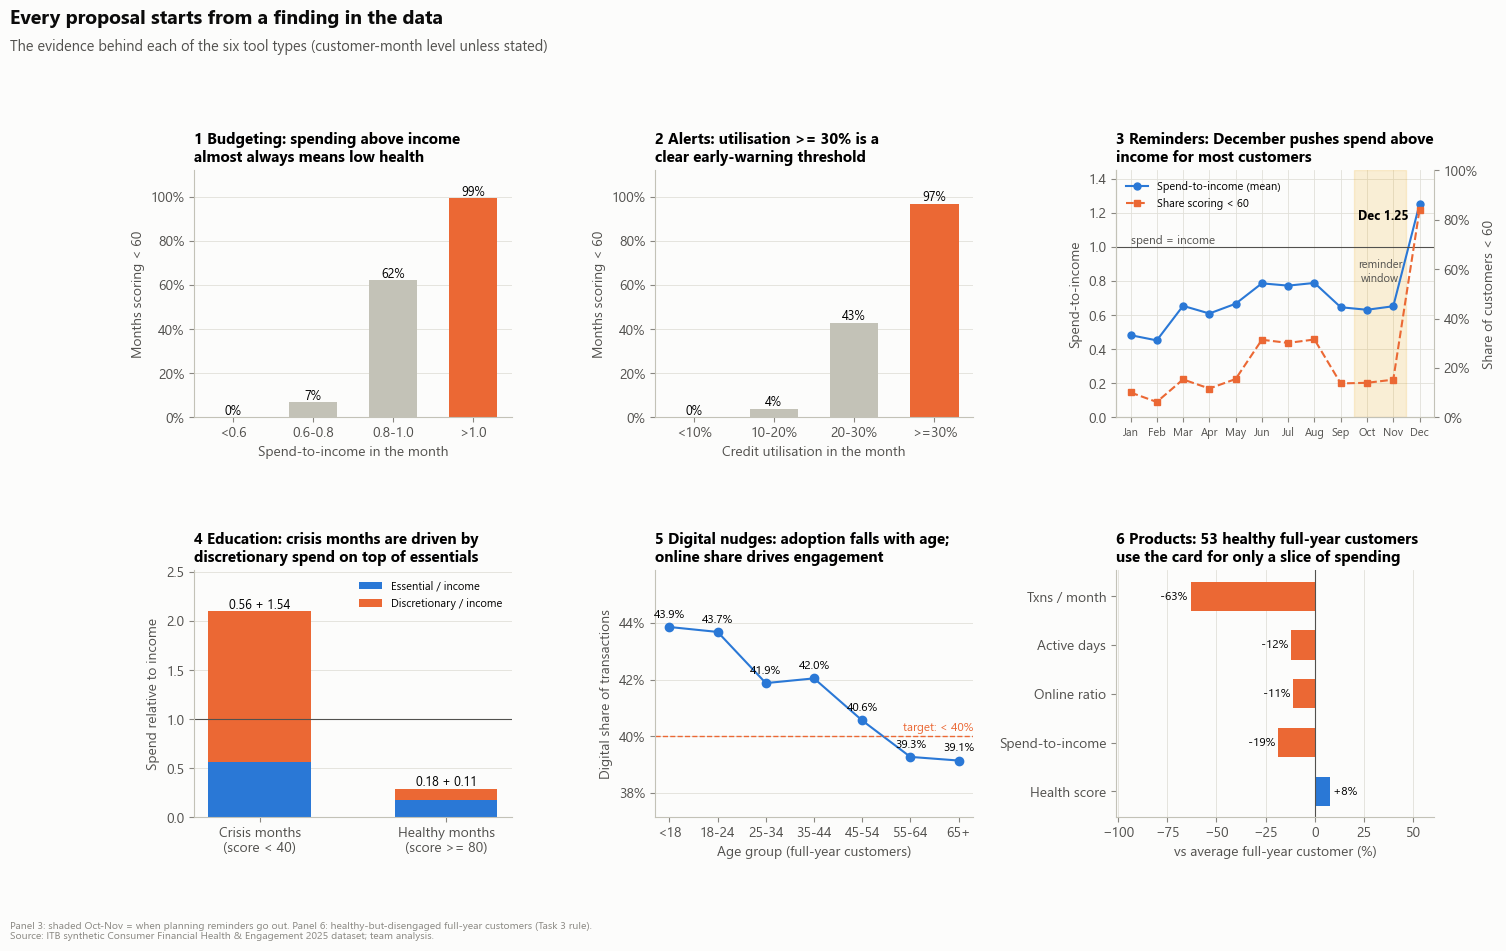

In [5]:
# Evidence grid: the finding behind each tool, one panel per tool
fig, axes = plt.subplots(2, 3, figsize=(16, 8.4), gridspec_kw={"hspace": 0.62, "wspace": 0.45})
A = axes.flat

ax = next(A)   # 1 budgeting
bands = pd.cut(m.spend_to_income_ratio, [0, 0.6, 0.8, 1.0, 100], labels=["<0.6", "0.6-0.8", "0.8-1.0", ">1.0"])
r = lo.groupby(bands, observed=True).mean()
ax.bar(r.index.astype(str), r.values, color=[GRAY, GRAY, GRAY, ORANGE], width=0.6)
for i, v in enumerate(r.values): ax.text(i, v, pct(v, 0), ha="center", va="bottom", fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0, 1.12); ax.grid(axis="x", visible=False)
ax.set_xlabel("Spend-to-income in the month"); ax.set_ylabel("Months scoring < 60")
ax.set_title("1 Budgeting: spending above income\nalmost always means low health")

ax = next(A)   # 2 alerts
bands = pd.cut(m.credit_utilization_ratio, [-0.01, 0.1, 0.2, 0.3, 10], labels=["<10%", "10-20%", "20-30%", ">=30%"])
r = lo.groupby(bands, observed=True).mean()
ax.bar(r.index.astype(str), r.values, color=[GRAY, GRAY, GRAY, ORANGE], width=0.6)
for i, v in enumerate(r.values): ax.text(i, v, pct(v, 0), ha="center", va="bottom", fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0, 1.12); ax.grid(axis="x", visible=False)
ax.set_xlabel("Credit utilisation in the month"); ax.set_ylabel("Months scoring < 60")
ax.set_title("2 Alerts: utilisation >= 30% is a\nclear early-warning threshold")

ax = next(A)   # 3 reminders
ax.plot(MONTHS, sti_m.values, color=BLUE, marker="o", ms=5, label="Spend-to-income (mean)")
ax.axhline(1, color=INK_2, lw=0.8); ax.text(0, 1.02, "spend = income", fontsize=8.5, color=INK_2)
ax2 = ax.twinx(); ax2.plot(MONTHS, low_m.values, color=ORANGE, marker="s", ms=4, ls="--", label="Share scoring < 60")
ax2.yaxis.set_major_formatter(PercentFormatter(1)); ax2.set_ylim(0, 1); ax2.grid(False); ax2.spines["right"].set_visible(True)
ax.set_ylim(0, 1.45); ax.set_ylabel("Spend-to-income"); ax2.set_ylabel("Share of customers < 60")
ax.annotate(f"Dec {sti_m[12]:.2f}", (11, sti_m[12]), xytext=(-8, -4), textcoords="offset points", ha="right", va="top", fontsize=9, fontweight="bold")
ax.axvspan(8.5, 10.5, color=YELLOW, alpha=0.15); ax.text(9.5, 0.93, "reminder\nwindow", ha="center", va="top", fontsize=8, color=INK_2)
ax.tick_params(axis="x", labelsize=8)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
ax.set_title("3 Reminders: December pushes spend above\nincome for most customers")

ax = next(A)   # 4 education
grp = ["Crisis months\n(score < 40)", "Healthy months\n(score >= 80)"]
ei = [(cr.essential_spend_vnd / cr.monthly_income_vnd).mean(), (hh.essential_spend_vnd / hh.monthly_income_vnd).mean()]
di = [cr.disc_to_income.mean(), hh.disc_to_income.mean()]
ax.bar(grp, ei, color=BLUE, width=0.55, label="Essential / income")
ax.bar(grp, di, bottom=ei, color=ORANGE, width=0.55, label="Discretionary / income")
for i in range(2): ax.text(i, ei[i] + di[i], f"{ei[i]:.2f} + {di[i]:.2f}", ha="center", va="bottom", fontsize=9)
ax.axhline(1, color=INK_2, lw=0.8); ax.set_ylim(0, (ei[0] + di[0]) * 1.2); ax.grid(axis="x", visible=False)
ax.set_ylabel("Spend relative to income"); ax.legend(fontsize=8, loc="upper right")
ax.set_title("4 Education: crisis months are driven by\ndiscretionary spend on top of essentials")

ax = next(A)   # 5 digital
ax.plot(dig_age.index.astype(str), dig_age.values, color=BLUE, marker="o", ms=6)
for i, v in enumerate(dig_age.values): ax.annotate(pct(v), (i, v), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8.5)
ax.axhline(0.40, color=ORANGE, lw=1, ls="--"); ax.text(6.3, 0.401, "target: < 40%", ha="right", va="bottom", fontsize=8.5, color=ORANGE)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.set_ylim(dig_age.min() - 0.02, dig_age.max() + 0.02)
ax.set_xlabel("Age group (full-year customers)"); ax.set_ylabel("Digital share of transactions"); ax.grid(axis="x", visible=False)
ax.set_title("5 Digital nudges: adoption falls with age;\nonline share drives engagement")

ax = next(A)   # 6 products
show = {"transaction_count": "Txns / month", "active_transaction_days": "Active days", "online_spend_ratio": "Online ratio",
        "spend_to_income_ratio": "Spend-to-income", "financial_health_score": "Health score"}
rel = (hdf[list(show)].mean() / fy[list(show)].mean() - 1) * 100
ax.barh(list(show.values())[::-1], rel.values[::-1], color=[BLUE if v > 0 else ORANGE for v in rel.values[::-1]], height=0.6)
for i, v in enumerate(rel.values[::-1]): ax.text(v, i, f" {v:+.0f}% " , ha="left" if v >= 0 else "right", va="center", fontsize=8.5)
ax.axvline(0, color=INK_2, lw=0.8); lim = rel.abs().max() * 1.6; ax.set_xlim(-lim, lim * 0.6); ax.grid(axis="y", visible=False)
ax.set_xlabel("vs average full-year customer (%)")
ax.set_title(f"6 Products: {len(hdf)} healthy full-year customers\nuse the card for only a slice of spending")

show_chart(fig, title="Every proposal starts from a finding in the data",
           subtitle="The evidence behind each of the six tool types (customer-month level unless stated)",
           note="Panel 3: shaded Oct-Nov = when planning reminders go out. Panel 6: healthy-but-disengaged full-year customers (Task 3 rule).")

## 4. The action plan: one proposal per tool type

In [6]:
proposal = {
    "1 Budgeting tool": "In-app monthly budget that projects month-end spend against income and suggests a category plan when the projection exceeds income.",
    "2 Spend alerts": "Real-time alert when credit utilisation crosses 30%, with a one-tap view of the categories driving it; customers can choose their own threshold.",
    "3 Planning reminders": "Oct-Nov reminder to set a year-end budget, plus a mid-December check-in showing spend-to-income so far.",
    "4 Education content": "Short 'needs vs wants' and 'planning big purchases (e.g. travel)' modules, shown after a month where discretionary spend passes income.",
    "5 Digital nudges": "(a) Assisted QR / app set-up and bill auto-pay for 55+ customers who mostly pay at POS; (b) second-month activation journey for customers with only 1-2 observed months.",
    "6 Product suggestions": "Savings-goal account and cashback on everyday categories (fuel, groceries: the top categories in Task 1 Q4) to win share of wallet from healthy but inactive customers.",
}
column = {"1 Budgeting tool": "spend_to_income_ratio", "2 Spend alerts": "credit_utilization_ratio",
          "3 Planning reminders": "spend_to_income_ratio (Dec)", "4 Education content": "discretionary_spend_vnd / monthly_income_vnd",
          "5 Digital nudges": "digital_txn_share, age, segment", "6 Product suggestions": "financial_health_score, engagement_score"}
plan = reach.join(EV)
plan.insert(0, "proposal", pd.Series(proposal)); plan.insert(1, "data column", pd.Series(column))
# Ranking: reach and driver strength, each scaled to 0-1 by its maximum, averaged
plan["reach_score"] = plan.customers / plan.customers.max()
plan["driver_score"] = plan.driver_strength / plan.driver_strength.max()
plan["priority_score"] = ((plan.reach_score + plan.driver_score) / 2).round(3)
plan["rank"] = plan.priority_score.rank(ascending=False, method="min").astype(int)
plan = plan.sort_values("rank")
plan.to_csv(OUT / "t5_action_plan.csv", encoding="utf-8-sig")
plan[["rank", "proposal", "data column", "customers", "% of 999", "evidence", "driver", "driver_strength", "priority_score"]]

,rank,proposal,data column,customers,% of 999,evidence,driver,driver_strength,priority_score
3 Planning reminders,1,"Oct-Nov reminder to set a year-end budget, plus a mid-December check-in showing spend-...",spend_to_income_ratio (Dec),687,68.8,December spend-to-income 1.25 vs 0.45-0.79; 84.1% of customers score < 60 in December,spend-to-income vs health (December),0.82,0.932
2 Spend alerts,2,"Real-time alert when credit utilisation crosses 30%, with a one-tap view of the catego...",credit_utilization_ratio,592,59.3,Months with utilisation >= 30%: 96.9% score < 60 vs 14.1% otherwise,credit utilisation vs health,0.87,0.889
1 Budgeting tool,3,In-app monthly budget that projects month-end spend against income and suggests a cate...,spend_to_income_ratio,489,48.9,"Months with spend > income: 99.3% score < 60 vs 11.5% otherwise (1,470 customer-months...",spend-to-income vs health,0.95,0.856
5 Digital nudges,4,(a) Assisted QR / app set-up and bill auto-pay for 55+ customers who mostly pay at POS...,"digital_txn_share, age, segment",294,29.4,Digital share 43.9% (<18) falls to 39.1% (65+); engagement 71.3 in the lowest vs 83.9 ...,online spend ratio vs engagement,0.83,0.651
4 Education content,5,"Short 'needs vs wants' and 'planning big purchases (e.g. travel)' modules, shown after...",discretionary_spend_vnd / monthly_income_vnd,70,7.0,Crisis months: 71.6% discretionary vs 40.5% in healthy months; discretionary = 1.54x i...,discretionary spend / income vs health,0.93,0.540
6 Product suggestions,6,"Savings-goal account and cashback on everyday categories (fuel, groceries: the top cat...","financial_health_score, engagement_score",85,8.5,Healthy (mean score 72.1) but full-year members make 63% fewer transactions than a typ...,transactions / month vs engagement,0.50,0.325


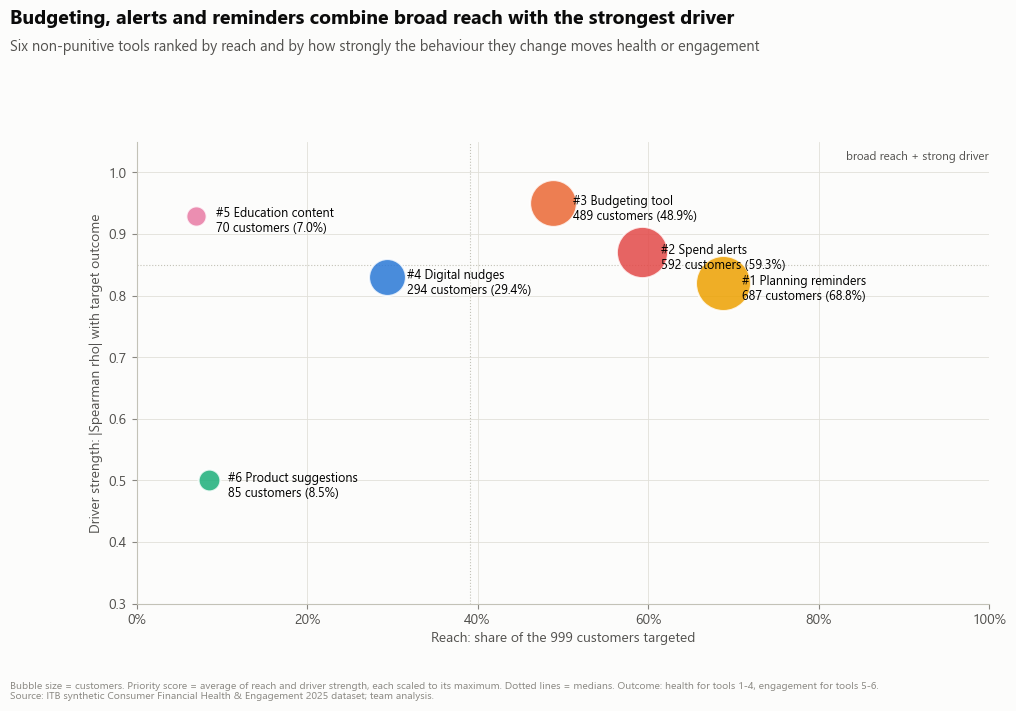

In [7]:
# Prioritisation map: reach (x) vs driver strength (y)
fig, ax = plt.subplots(figsize=(11, 6))
col = {t: c_ for t, c_ in zip(TOOLS, [ORANGE, RED, YELLOW, MAGENTA, BLUE, AQUA])}
for t, r in plan.iterrows():
    ax.scatter(r["% of 999"], r.driver_strength, s=r.customers * 2.2 + 60, color=col[t], alpha=0.85, edgecolor="white", lw=1.5, zorder=3)
    ax.annotate(f"#{r['rank']} {t[2:]}\n{r.customers} customers ({r['% of 999']}%)", (r["% of 999"], r.driver_strength),
                xytext=(14, -4), textcoords="offset points", fontsize=9, va="center")
xm, ym = plan["% of 999"].median(), plan.driver_strength.median()
ax.axvline(xm, color=GRAY, lw=0.8, ls=":"); ax.axhline(ym, color=GRAY, lw=0.8, ls=":")
ax.text(100, 1.02, "broad reach + strong driver", ha="right", fontsize=8.5, color=INK_2)
ax.set_xlim(0, 100); ax.set_ylim(0.3, 1.05)
ax.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax.set_xlabel("Reach: share of the 999 customers targeted"); ax.set_ylabel("Driver strength: |Spearman rho| with target outcome")
show_chart(fig, title="Budgeting, alerts and reminders combine broad reach with the strongest driver",
           subtitle="Six non-punitive tools ranked by reach and by how strongly the behaviour they change moves health or engagement",
           note="Bubble size = customers. Priority score = average of reach and driver strength, each scaled to its maximum. "
                "Dotted lines = medians. Outcome: health for tools 1-4, engagement for tools 5-6.")

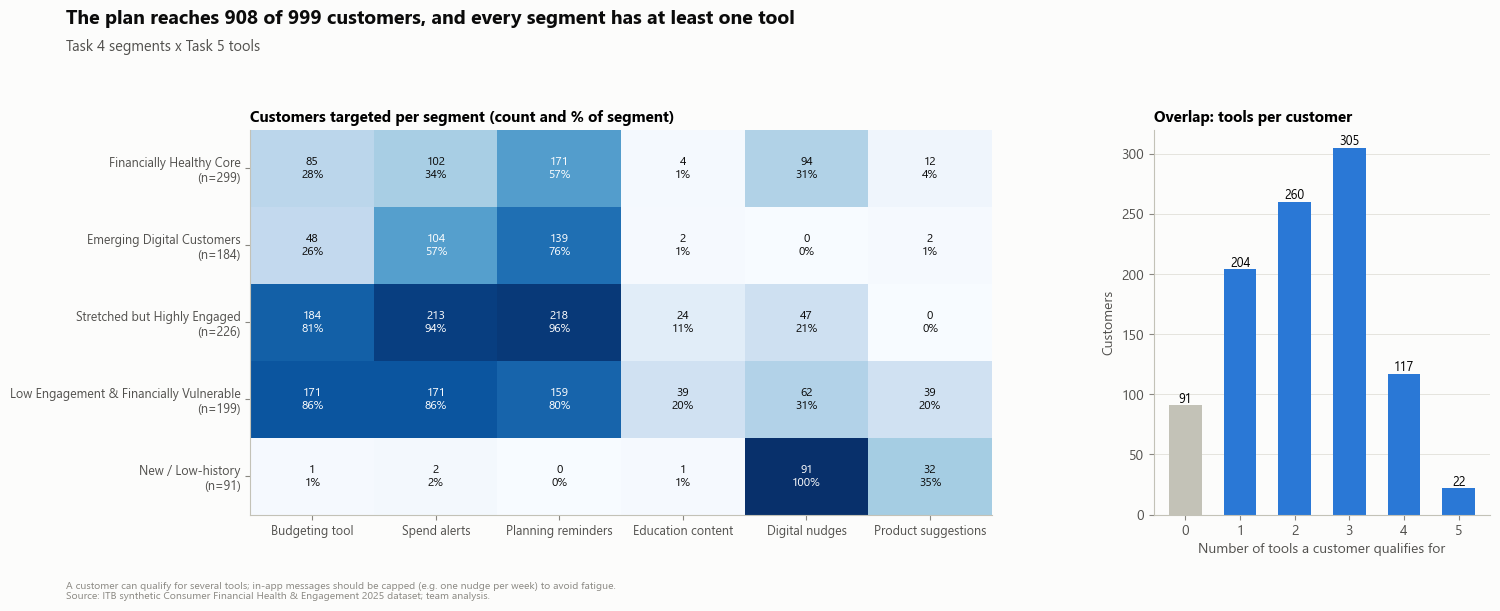

In [8]:
# Coverage: who receives what (Task 4 segments x tools), and how many tools per customer
cov = T.groupby(c.segment).sum().reindex(SEG_ORDER)
cov_pct = cov.div(c.segment.value_counts().reindex(SEG_ORDER), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [2.2, 1], "wspace": 0.3})
ax = axes[0]
im = ax.imshow(cov_pct.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(TOOLS)), [t[2:] for t in TOOLS], fontsize=9, rotation=0)
ax.set_yticks(range(len(SEG_ORDER)), [f"{s}\n(n={int((c.segment == s).sum())})" for s in SEG_ORDER], fontsize=9); ax.grid(False)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov_pct.iloc[i, j]
        ax.text(j, i, f"{cov.iloc[i, j]}\n{pct(v, 0)}", ha="center", va="center", fontsize=8.5, color="white" if v > 0.55 else INK)
ax.set_title("Customers targeted per segment (count and % of segment)")
ax = axes[1]
k = T.sum(axis=1).value_counts().sort_index()
ax.bar(k.index.astype(str), k.values, color=[GRAY] + [BLUE] * (len(k) - 1), width=0.6)
for i, v in enumerate(k.values): ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Number of tools a customer qualifies for"); ax.set_ylabel("Customers"); ax.grid(axis="x", visible=False)
ax.set_title("Overlap: tools per customer")
show_chart(fig, title=f"The plan reaches {int(T.any(axis=1).sum())} of {N} customers, and every segment has at least one tool",
           subtitle="Task 4 segments x Task 5 tools",
           note="A customer can qualify for several tools; in-app messages should be capped (e.g. one nudge per week) to avoid fatigue.")
cov.to_csv(OUT / "t5_coverage_by_segment.csv", encoding="utf-8-sig")

### Ranked action plan

| Rank | Tool type | Target group (rule) | Customers | Evidence from the data | Driver (\|ρ\|) |
|---|---|---|---|---|---|
| 1 | **Financial-planning reminders** | Spent more than income in December | **687 (68.8%)** | Dec spend-to-income 1.25 vs 0.45-0.79 in other months; 84.1% of customers score < 60 in December | 0.82 |
| 2 | **Spend alerts** | Credit utilisation ≥ 30% in ≥1 month | **592 (59.3%)** | 96.9% of such months score < 60, vs 14.1% otherwise | 0.87 |
| 3 | **Budgeting tool** | Spent more than income in ≥1 month outside December | **489 (48.9%)** | 99.3% of spend > income months score < 60, vs 11.5% otherwise | 0.95 |
| 4 | **Digital-channel nudges** | 55+ full-year customers with digital share < 40% (203) + New / Low-history (91) | **294 (29.4%)** | Digital share falls from 43.9% (<18) to 39.1% (65+); engagement rises from 71.3 to 83.9 across online-ratio quintiles | 0.83 |
| 5 | **Financial-education content** | ≥1 crisis month (score < 40) | **70 (7.0%)** | Crisis months: 71.6% discretionary vs 40.5%; discretionary = 1.54x income vs 0.11x | 0.93 |
| 6 | **Suitable product suggestions** | Healthy but disengaged (Task 3) | **85 (8.5%)** | Mean health 72.1, but full-year members make 63% fewer transactions | 0.50 |

**Reading the plan**
- **Tools 1-3 form one spend-control journey** around the dominant health driver, spend-to-income (81% of score variance, Task 2): a *reminder* before the December peak, an *alert* when utilisation crosses 30%, and a *budget* to plan the following month. Together they cover 81-96% of the **Stretched but Highly Engaged** segment and 80-86% of **Low Engagement & Financially Vulnerable**.
- **Education content** has a strong driver (0.93) but a narrow target of 70 customers who had a crisis month. It is a precise, high-intensity intervention, not a mass campaign.
- **Digital nudges** are the only tool aimed at engagement at scale, and the only one that reaches all 91 **New / Low-history** customers.
- **Product suggestions** rank last (small group, weaker driver). These are healthy, low-risk customers, so the goal is share of wallet and retention, not risk reduction.
- **908 of 999 customers (90.9%)** qualify for at least one tool, and 444 for three or more. Of the 91 with no tool, 90 are in the Healthy Core or Emerging Digital segments. In-app messaging should be capped to avoid fatigue.

## 5. Credit-decision rule and guardrails

In [9]:
# Guardrail: the only outputs are offer flags; there is no credit-action column
targets = T.copy(); targets.columns = [f"offer_{t[2:].lower().replace(' ', '_')}" for t in TOOLS]
targets["segment"] = c.segment
forbidden = [k for k in targets.columns if any(w in k for w in ("deny", "decline", "limit", "block", "credit"))]
assert not forbidden, forbidden
targets.to_csv(OUT / "t5_customer_offers.csv", encoding="utf-8-sig")
print("Exported", targets.shape, "-> only 'offer_*' flags; no credit-action fields:", forbidden == [])

# Fairness check: offer rates by gender and age group (offers are opt-in support, so no group should be excluded)
chk = pd.concat({"gender": T.groupby(c.gender).mean(), "age group": T.groupby(c.age_group, observed=True).mean()})
(chk * 100).round(1)

Exported (999, 7) -> only 'offer_*' flags; no credit-action fields: True


1 Budgeting tool  2 Spend alerts  3 Planning reminders  4 Education content  5 Digital nudges  6 Product suggestions
gender    Nam                52.8            62.6                  69.0                  6.9              30.8                    9.5
          Nữ                 45.1            56.0                  68.5                  7.1              28.1                    7.5
age group <18                28.6            71.4                 100.0                  0.0               0.0                    0.0
          18-24              32.3            30.6                  46.8                  6.5              29.0                    9.7
          25-34              53.1            65.0                  80.8                  9.0               0.0                    4.0
          35-44              46.7            63.6                  78.2                  3.0               0.0                    4.2
          45-54              53.0            65.2                  73.7                 10.6               6.1                    7.6
          55-64              50.9            54.3                  60.0                  5.1              70.9                   15.4
          65+                47.4            57.7                  59.5                  7.0              65.1                   10.7

### Credit-decision rule (applies to every proposal)
> `financial_health_score`, the Task 4 segments and every targeting flag in this plan are used **only to offer optional support**: tools, alerts, reminders, content, nudges and products. They must **never** be used to approve or deny credit, reduce a credit limit, or block or restrict an account.

- The exported file `outputs_task5/t5_customer_offers.csv` contains only `offer_*` flags. The check above confirms it has no credit-action field.
- Customers can opt out of any tool and set their own alert threshold.
- **Fairness:**
  - Offer rates are similar for men and women (budgeting 52.8% vs 45.1%; reminders 69.0% vs 68.5%).
  - Differences by age follow each rule's purpose. Digital nudges go mainly to customers aged 55+ (65-71%) by design, and product suggestions skew older because healthy-but-disengaged customers are older (Task 3).
  - No one is excluded from a benefit: every tool remains available on request to all customers.